# Student Performance Indicator


## Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

## 1. Problem statement

- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

## 2. Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages

####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

#### Import the CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv("data.csv")

#### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

## 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing Values

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There is no missing values in the dataset

### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

There is no duplicated values in the dataset

Code to remove duplicate:

    df.drop_duplicates(inplace="True",keep="last") keep="first" is default value

### 3.3 Check Data Type

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Check the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.6 Check various categories present in the different categorical column

In [10]:
print("Categories in 'gender' variable:",end=" ")
print(df['gender'].unique())
print("Categories in 'race/ethenicity' variable:",end=" ")
print(df['race_ethnicity'].unique())
print("Categories in 'parental level of education' variable:",end=" ")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' variable:",end=" ")
print(df['lunch'].unique())
print("Categories in 'test preparation course' variable:",end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable: ['female' 'male']
Categories in 'race/ethenicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test preparation course' variable: ['none' 'completed']


### 3.7 Define Numerical And Categorical Columns

In [11]:
numeric_features = df.select_dtypes(exclude=['object']).columns
categorical_features = df.select_dtypes(include=['object']).columns

# Print Columns
print("We have {} numeric features : {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 3 numeric features : Index(['math_score', 'reading_score', 'writing_score'], dtype='object')
We have 5 categorical features : Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')


In [12]:
reading_full=df[df['reading_score']==100]['reading_score'].count()
math_full=df[df['math_score']==100]['math_score'].count()
writing_full=df[df['writing_score']==100]['writing_score'].count()

print(f"Number of students with full marks in reading: {reading_full}")
print(f"Number of students with full marks in math: {math_full}")
print(f"Number of students with full marks in writing: {writing_full}")

Number of students with full marks in reading: 17
Number of students with full marks in math: 7
Number of students with full marks in writing: 14


In [13]:
reading_less_20=df[df['reading_score']<=20]['reading_score'].count()
math_less_20=df[df['math_score']<=20]['math_score'].count()
writing_less_20=df[df['writing_score']<=20]['writing_score'].count()

print(f"Number of students with less than 20 marks in reading: {reading_less_20}")
print(f"Number of students with less than 20  marks in math: {math_less_20}")
print(f"Number of students with less than 20  marks in writing: {writing_less_20}")

Number of students with less than 20 marks in reading: 1
Number of students with less than 20  marks in math: 4
Number of students with less than 20  marks in writing: 3


#####  Insights

 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

## 4. FEATURE Engineering

### 4.1 Adding columns for "Total Score" and "Average"

In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [15]:
df['Total_Score'] = df[['math_score', 'reading_score', 'writing_score']].sum(axis=1)
df['Average_Score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


## 5. Exploring Data ( Visualization )

### 5.1 Visualize average score distribution to make some conclusion. 

- Histogram
- Kernel Distribution Function (KDE)

#### 5.1.1 Histogram & KDE

Text(0, 0.5, 'Frequency')

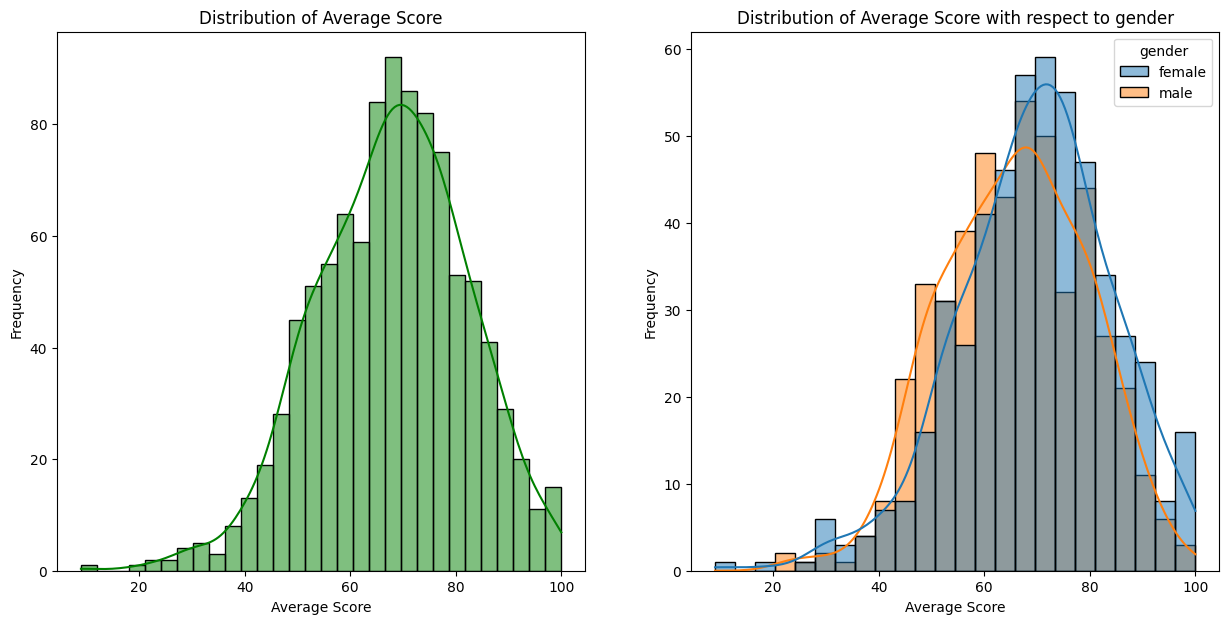

In [16]:
fig, ax = plt.subplots(1,2,figsize=(15, 7))
plt.subplot(1,2,1)
sns.histplot(data=df, x='Average_Score',bins=30, kde=True, color='green')
plt.title('Distribution of Average Score')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
sns.histplot(data=df, x='Average_Score',hue='gender', kde=True)
plt.title('Distribution of Average Score with respect to gender')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

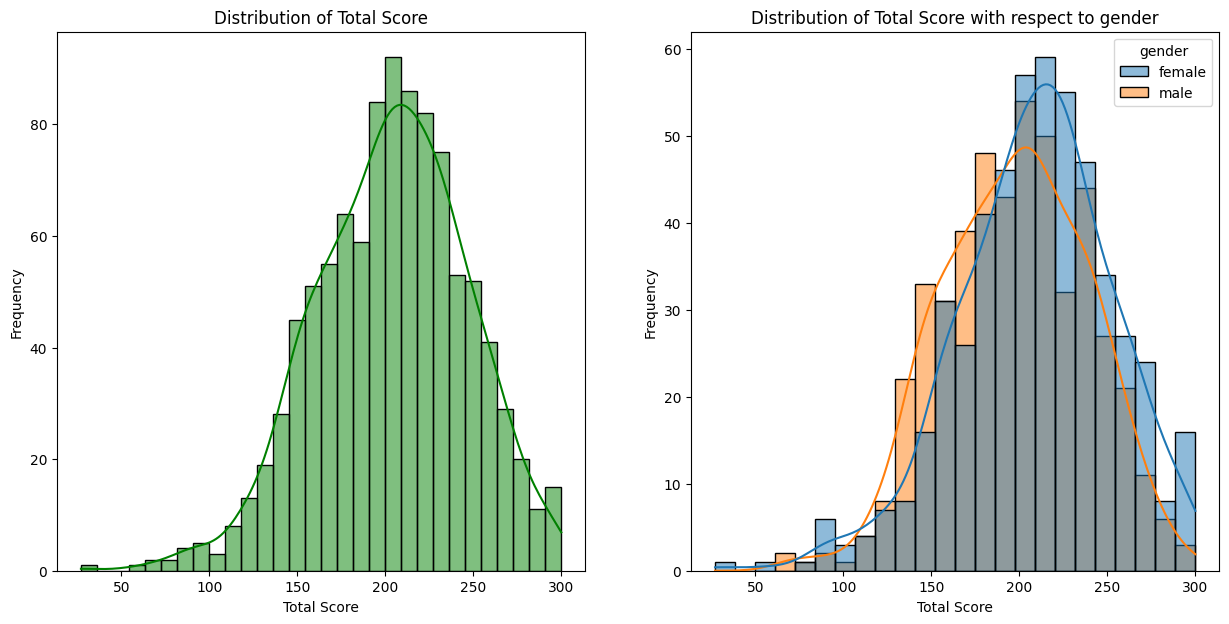

In [17]:
fig, ax = plt.subplots(1,2,figsize=(15, 7))
plt.subplot(1,2,1)
sns.histplot(data=df, x='Total_Score',bins=30, kde=True, color='green')
plt.title('Distribution of Total Score')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
sns.histplot(data=df, x='Total_Score',hue='gender', kde=True)
plt.title('Distribution of Total Score with respect to gender')
plt.xlabel('Total Score')
plt.ylabel('Frequency')

-->  Insights

- Female students tend to perform well then male students.

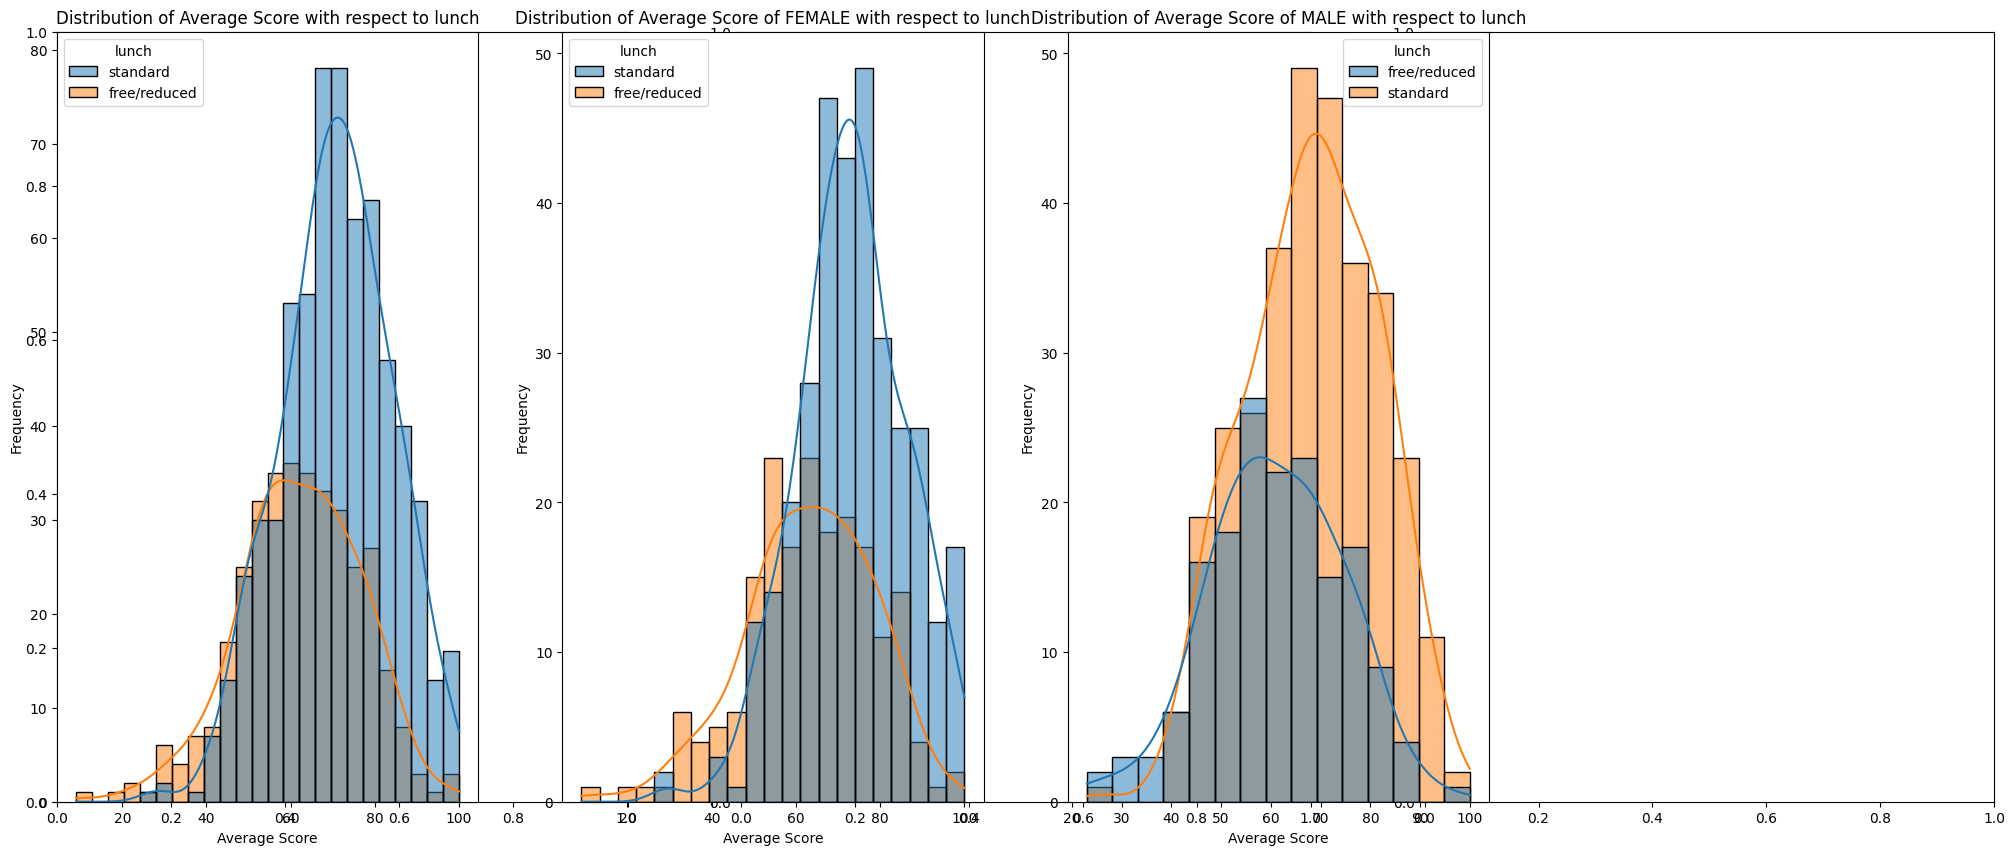

In [18]:
plt.subplots(1,3,figsize=(25,10))
plt.subplot(141)
sns.histplot(data=df,x='Average_Score',kde=True,hue='lunch')
plt.title('Distribution of Average Score with respect to lunch')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',kde=True,hue='lunch')
plt.title('Distribution of Average Score of FEMALE with respect to lunch')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',kde=True,hue='lunch')
plt.title('Distribution of Average Score of MALE with respect to lunch')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show()

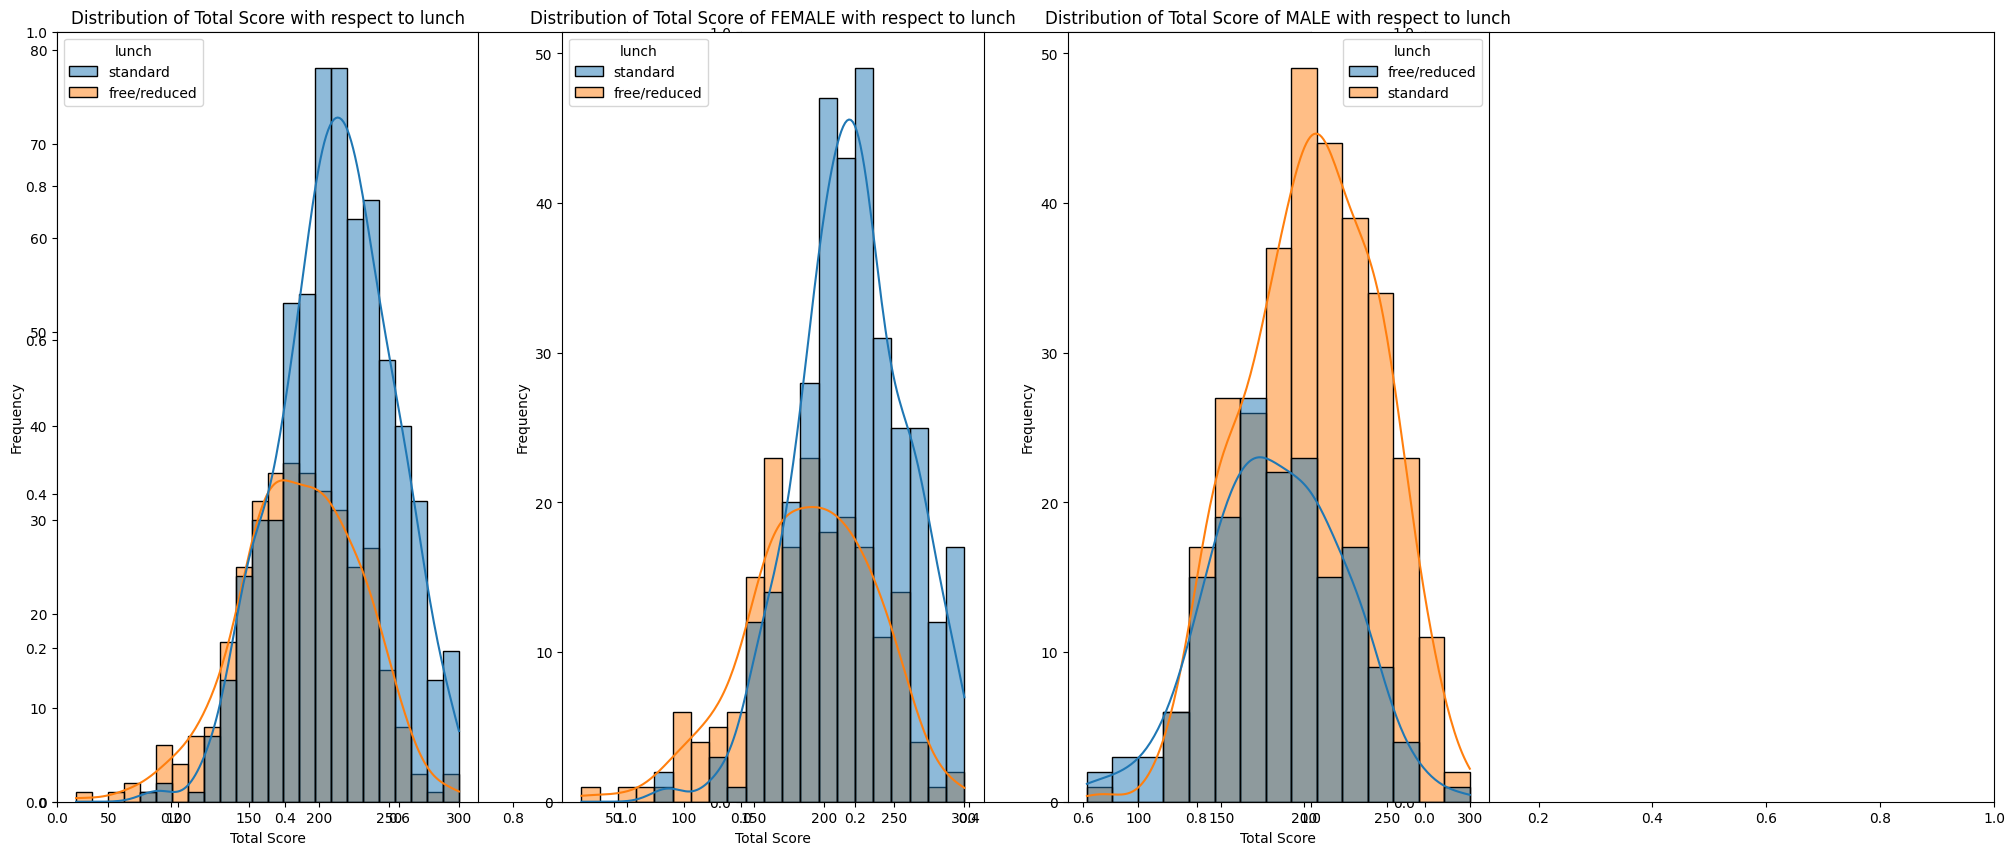

In [19]:
plt.subplots(1,3,figsize=(25,10))
plt.subplot(141)
sns.histplot(data=df,x='Total_Score',kde=True,hue='lunch')
plt.title('Distribution of Total Score with respect to lunch')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Total_Score',kde=True,hue='lunch')
plt.title('Distribution of Total Score of FEMALE with respect to lunch')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Total_Score',kde=True,hue='lunch')
plt.title('Distribution of Total Score of MALE with respect to lunch')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()

-->  Insights

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

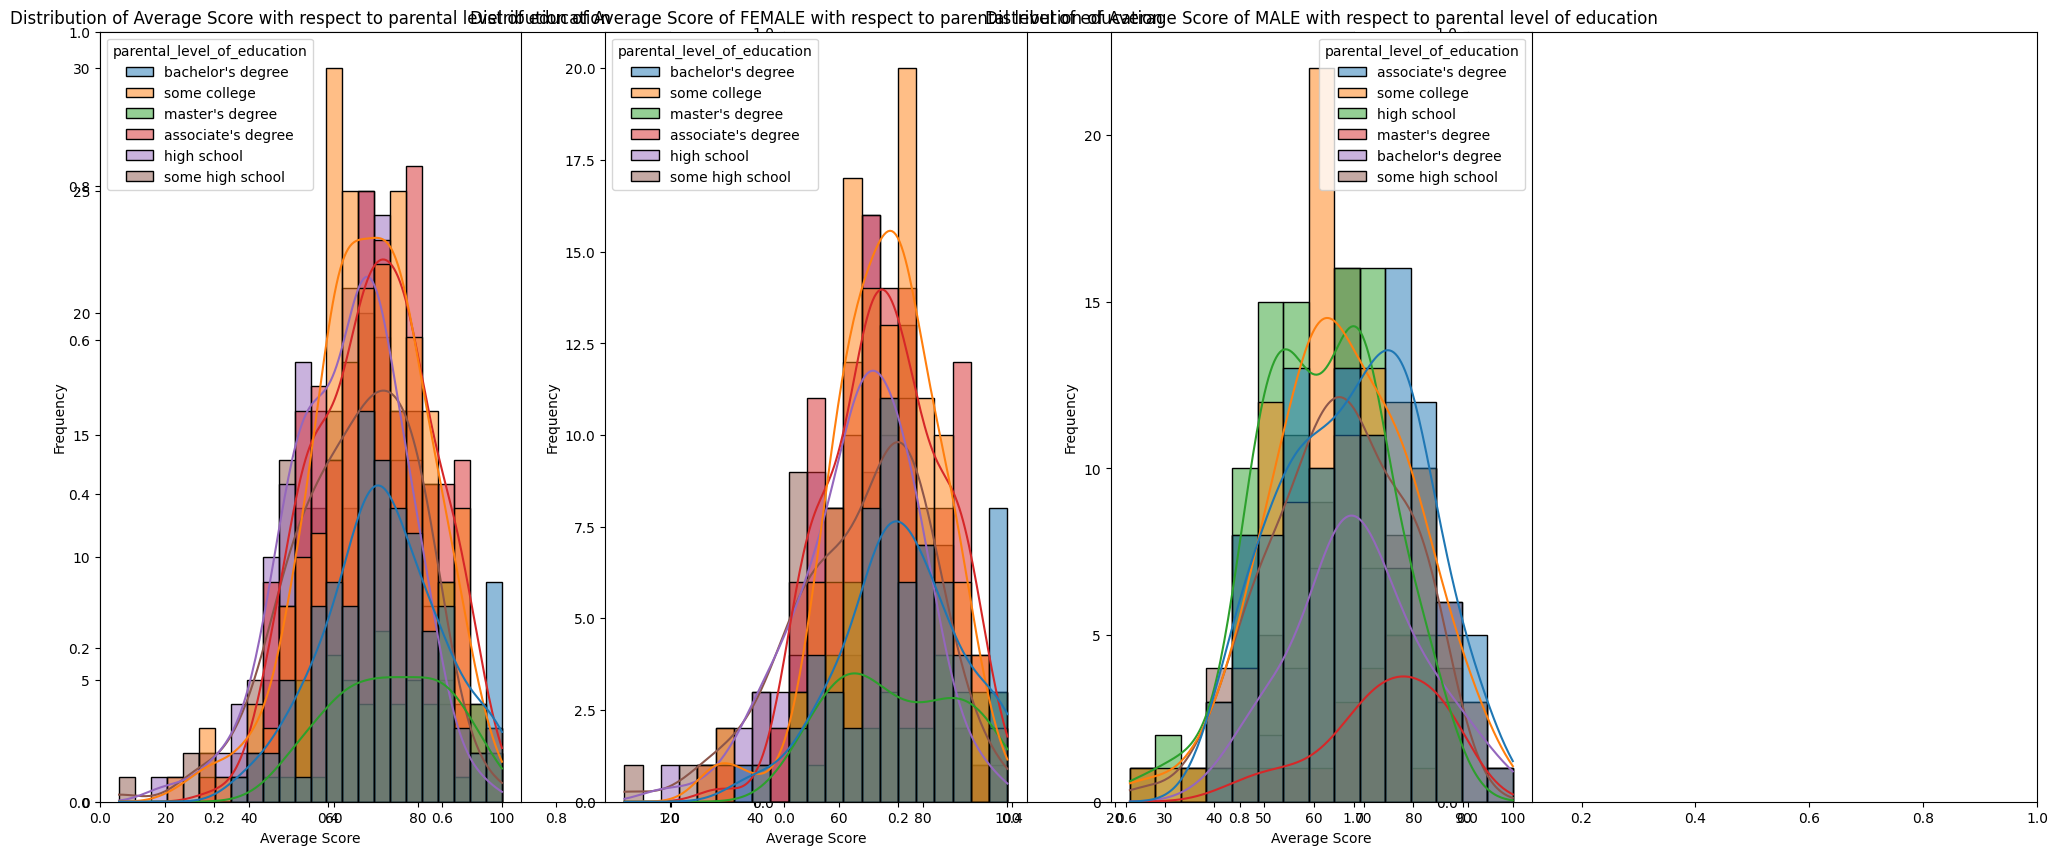

In [20]:
plt.subplots(1,3,figsize=(25,10))
plt.subplot(141)
sns.histplot(data=df,x='Average_Score',kde=True,hue='parental_level_of_education')
plt.title('Distribution of Average Score with respect to parental level of education')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',kde=True,hue='parental_level_of_education')
plt.title('Distribution of Average Score of FEMALE with respect to parental level of education')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',kde=True,hue='parental_level_of_education')
plt.title('Distribution of Average Score of MALE with respect to parental level of education')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show()

-->  Insights

- In general parent's education don't help student perform well in exam.
- 3rd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 2nd plot we can see there is no effect of parent's education on female students.

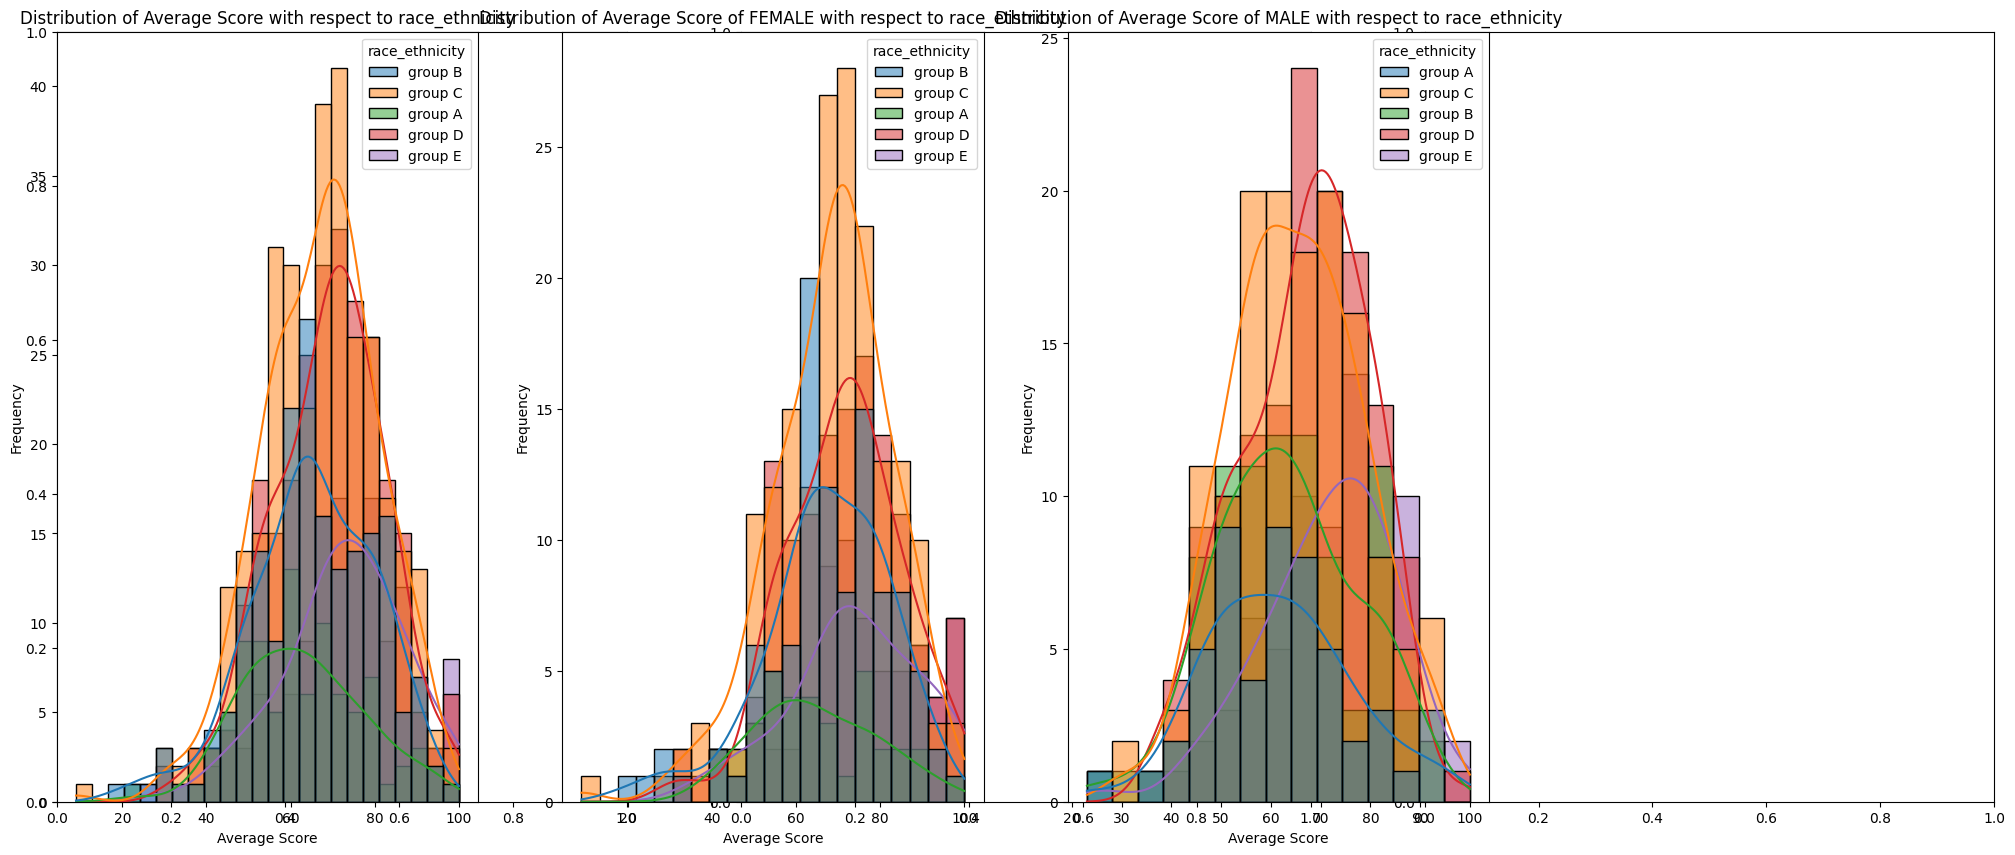

In [21]:
plt.subplots(1,3,figsize=(25,10))
plt.subplot(141)
sns.histplot(data=df,x='Average_Score',kde=True,hue='race_ethnicity')
plt.title('Distribution of Average Score with respect to race_ethnicity')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',kde=True,hue='race_ethnicity')
plt.title('Distribution of Average Score of FEMALE with respect to race_ethnicity')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',kde=True,hue='race_ethnicity')
plt.title('Distribution of Average Score of MALE with respect to race_ethnicity')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show()

--> Insights

- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

### 5.2 Maximumum score of students in all three subjects

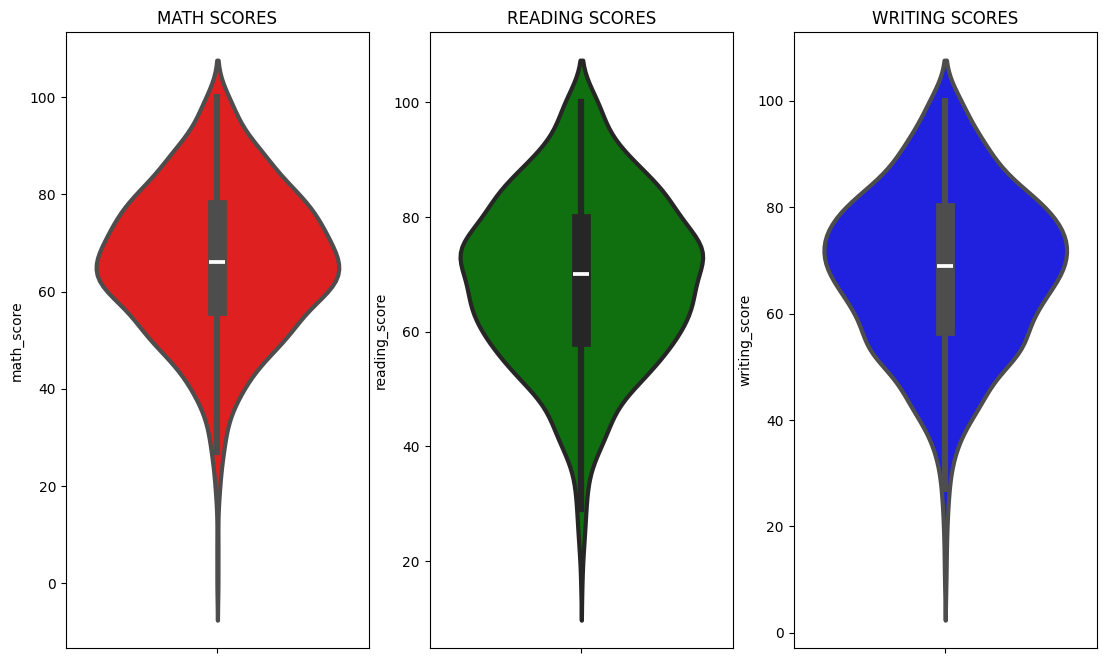

In [22]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

--> Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

### 5.3 Multivariate analysis using pieplot

In [23]:
df['test_preparation_course'].value_counts()

test_preparation_course
none         642
completed    358
Name: count, dtype: int64

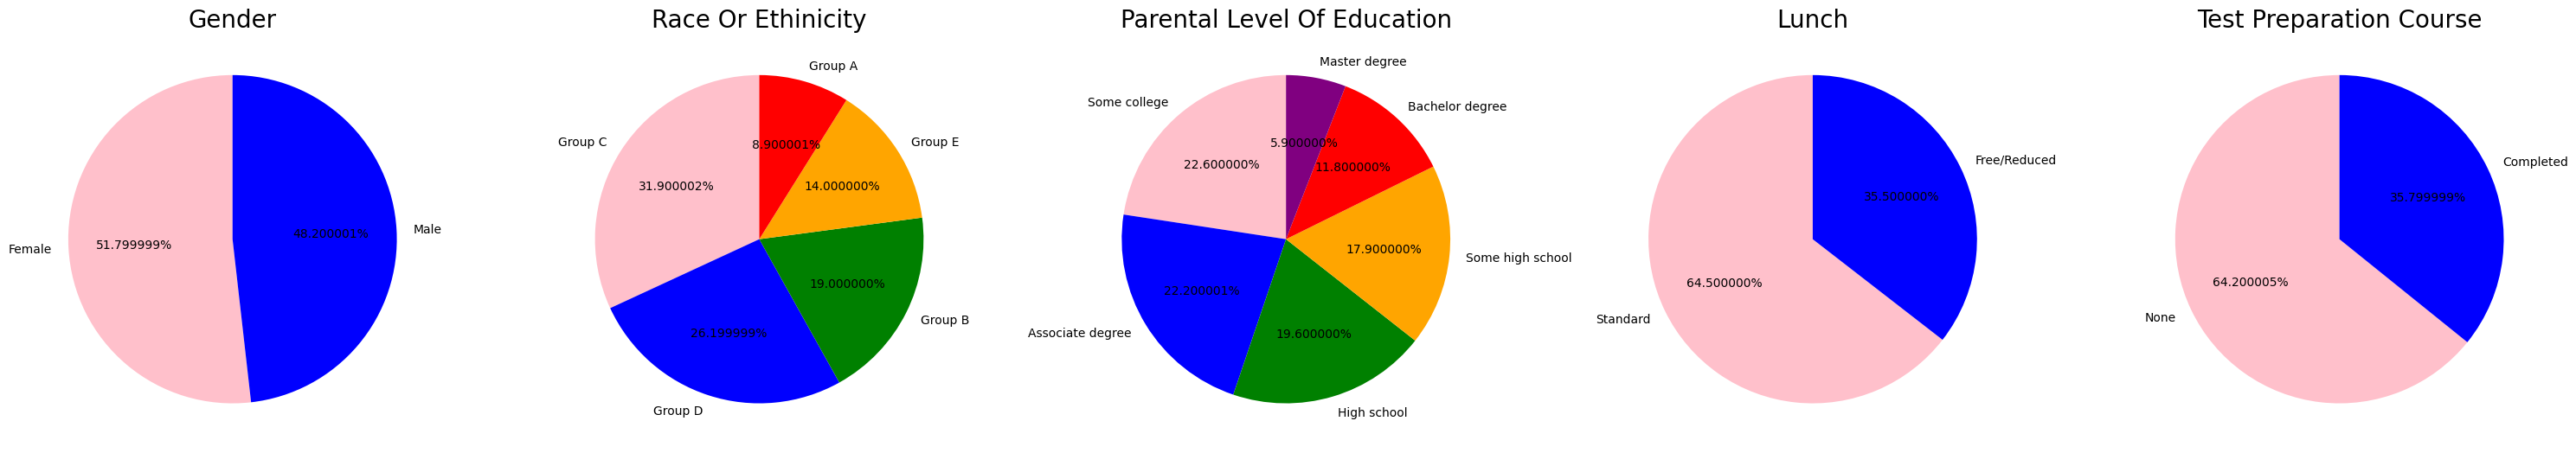

In [24]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels=['Female','Male']
colors=['Pink','Blue']

plt.pie(size,labels=labels,colors=colors,autopct='%2f%%',startangle=90)
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=df['race_ethnicity'].value_counts()
labels=['Group C','Group D','Group B','Group E','Group A']
colors=['Pink','Blue','Green','Orange','Red']

plt.pie(size,labels=labels,colors=colors,autopct='%2f%%',startangle=90)
plt.title('Race Or Ethinicity',fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size=df['parental_level_of_education'].value_counts()
labels=['Some college','Associate degree','High school','Some high school','Bachelor degree','Master degree']
colors=['Pink','Blue','Green','Orange','Red','Purple']

plt.pie(size,labels=labels,colors=colors,autopct='%2f%%',startangle=90)
plt.title('Parental Level Of Education',fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size=df['lunch'].value_counts()
labels=['Standard','Free/Reduced']
colors=['Pink','Blue']

plt.pie(size,labels=labels,colors=colors,autopct='%2f%%',startangle=90)
plt.title('Lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=df['test_preparation_course'].value_counts()
labels=['None','Completed']
colors=['Pink','Blue']

plt.pie(size,labels=labels,colors=colors,autopct='%2f%%',startangle=90)
plt.title('Test Preparation Course',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()


rcParams: This is a dictionary-like configuration manager in Matplotlib that controls the default styles and settings for plots (like font size, colors, figure size, etc.).

🔹 plt.tight_layout()
✅ What it does:
Automatically adjusts the spacing between subplots, axes labels, and titles to prevent overlap.

💡 Why it's useful:
When you're plotting things like:

multiple subplots

long axis labels

rotated tick labels
...this ensures everything is readable and doesn't clash.

🔹 plt.grid()
✅ What it does:
Turns on the grid lines in your current plot — makes the chart easier to read.

💡 Why it's useful:
Helps in visually aligning values

Great for presentations or when you’re analyzing numeric data

📌 By default:
It uses dashed lines and adds gridlines for both x and y axes.

-->  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### 5.4 Feature Wise Visualization

#### 5.4.1 GENDER COLUMN

- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

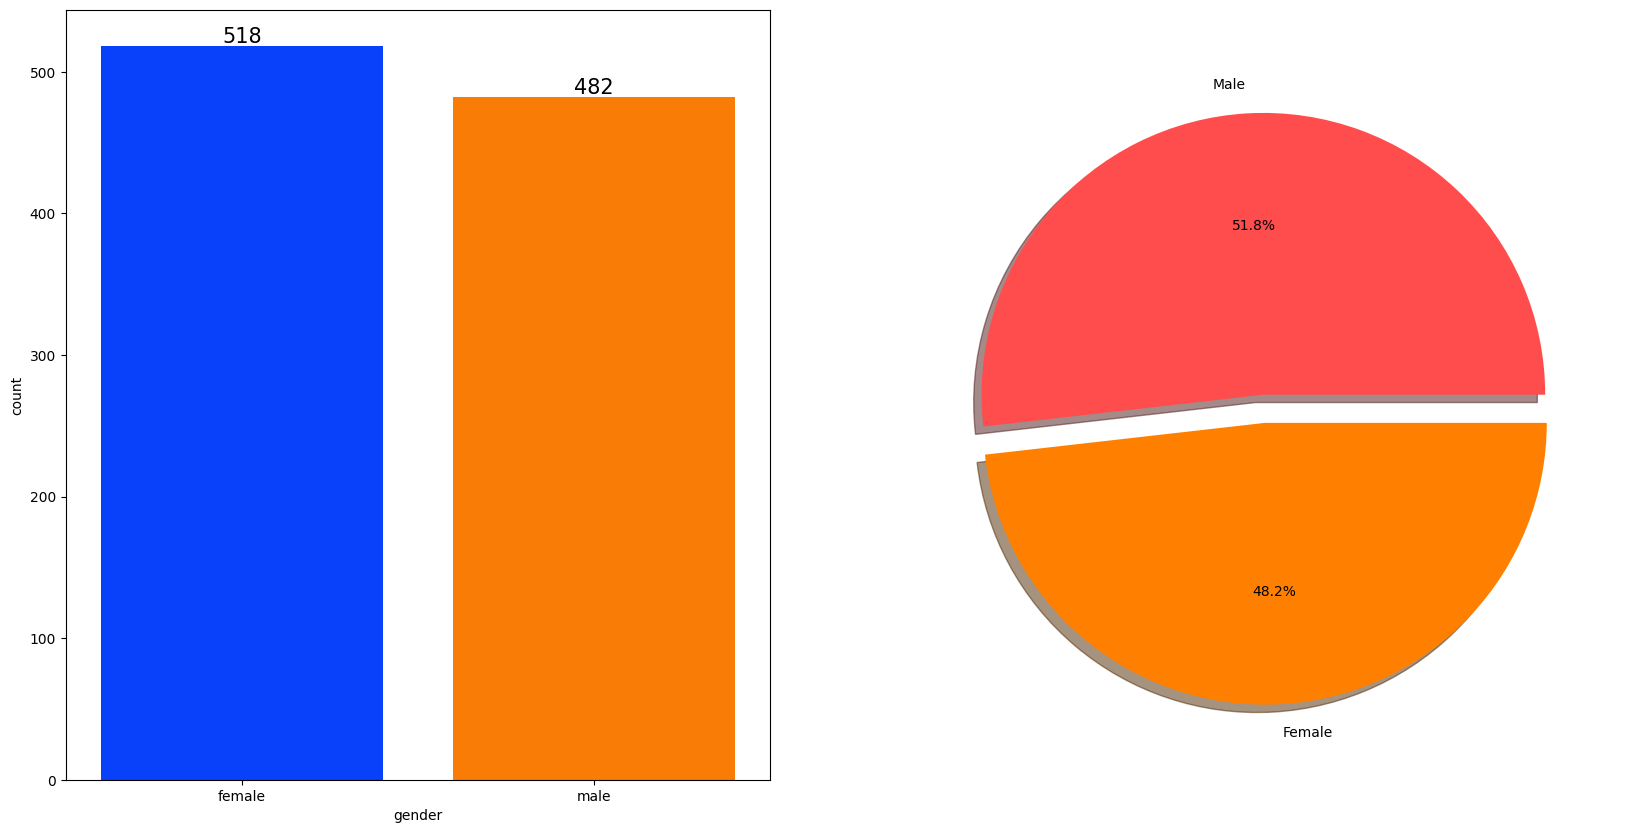

In [25]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for cont in ax[0].containers:
    ax[0].bar_label(cont, size=15, color='black')

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

--> Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

##### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 


In [27]:
gender_group = df.groupby('gender')[df.select_dtypes(include='number').columns].mean()
gender_group

,math_score,reading_score,writing_score,Total_Score,Average_Score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


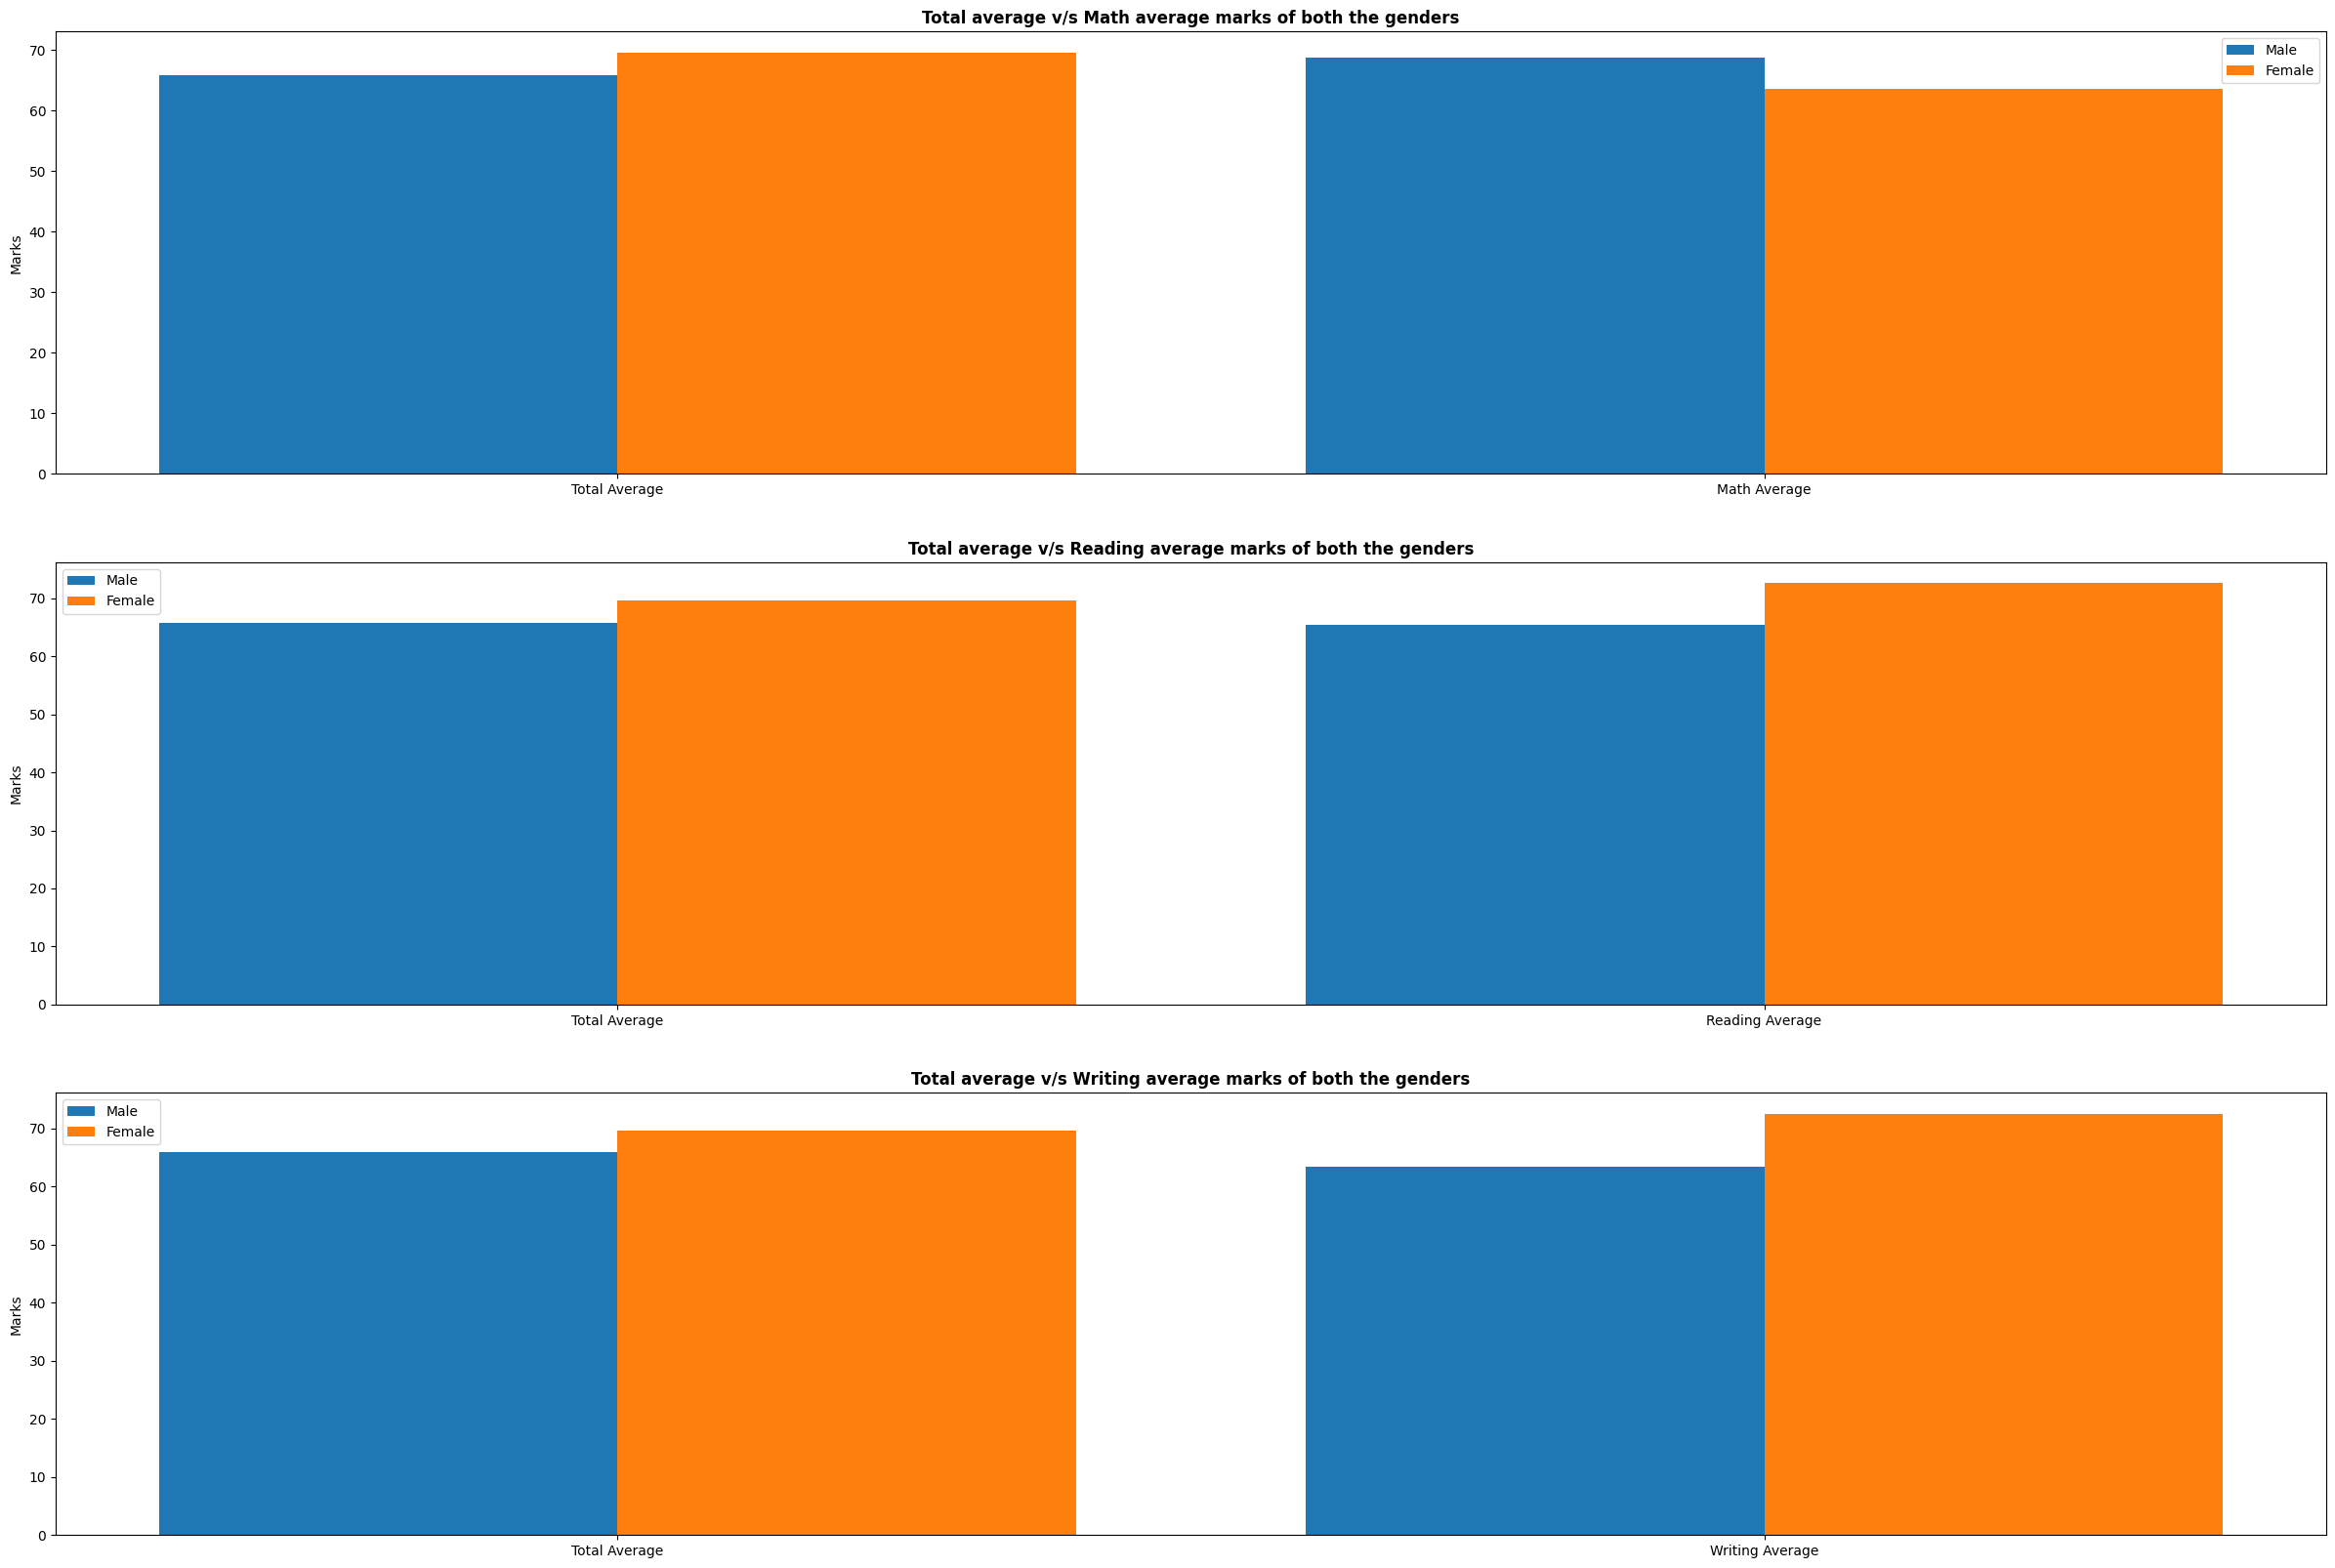

In [33]:
plt.figure(figsize=(30, 20))

X = ['Total Average','Math Average']

plt.subplot(3,1, 1)
female_scores = [gender_group['Average_Score'][0], gender_group['math_score'][0]]
male_scores = [gender_group['Average_Score'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()

plt.subplot(3,1, 2)
X = ['Total Average','Reading Average']
female_scores = [gender_group['Average_Score'][0], gender_group['reading_score'][0]]
male_scores = [gender_group['Average_Score'][1], gender_group['reading_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Reading average marks of both the genders", fontweight='bold')
plt.legend()

plt.subplot(3,1, 3)
X = ['Total Average','Writing Average']
female_scores = [gender_group['Average_Score'][0], gender_group['writing_score'][0]]
male_scores = [gender_group['Average_Score'][1], gender_group['writing_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Writing average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()
  

--> Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.
- In Reading and writing Average, females have scored more

#### 5.4.2 RACE/ETHINICITY COLUMN

- How is Group wise distribution ?
- Is Race/Ethinicity has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

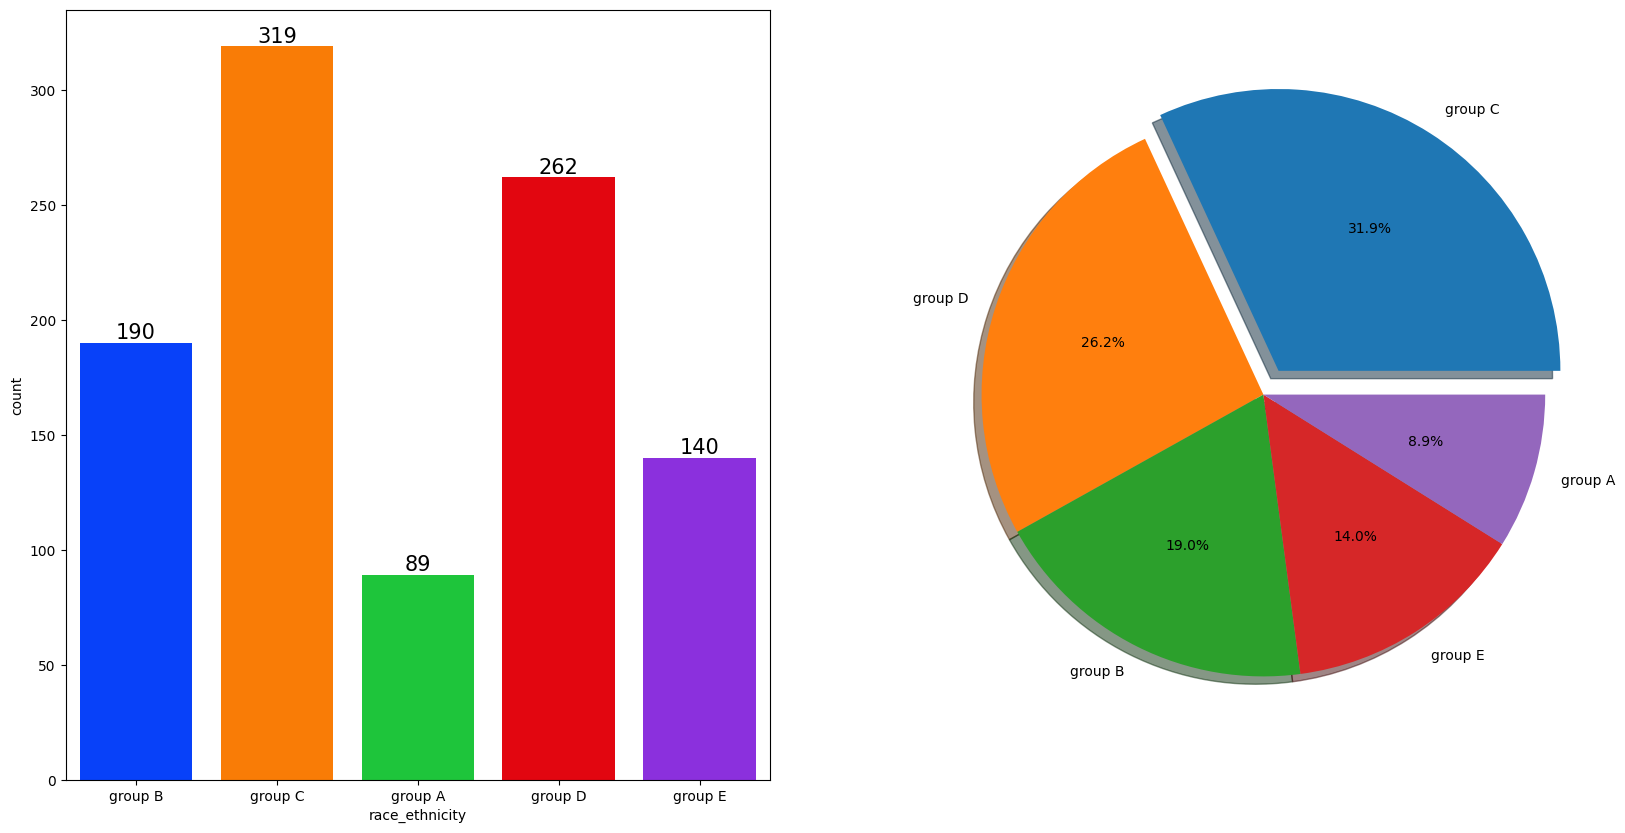

In [34]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for cont in ax[0].containers:
    ax[0].bar_label(cont, size=15, color='black')

plt.pie(x=df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()

--> Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

##### BIVARIATE ANALYSIS ( Is Race/Ethinicity has any impact on student's performance ? )

In [ ]:
Race_group=df.groupby('race_ethnicity')[df.select_dtypes(include='number').columns].mean()
Race_group

,math_score,reading_score,writing_score,Total_Score,Average_Score
race_ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


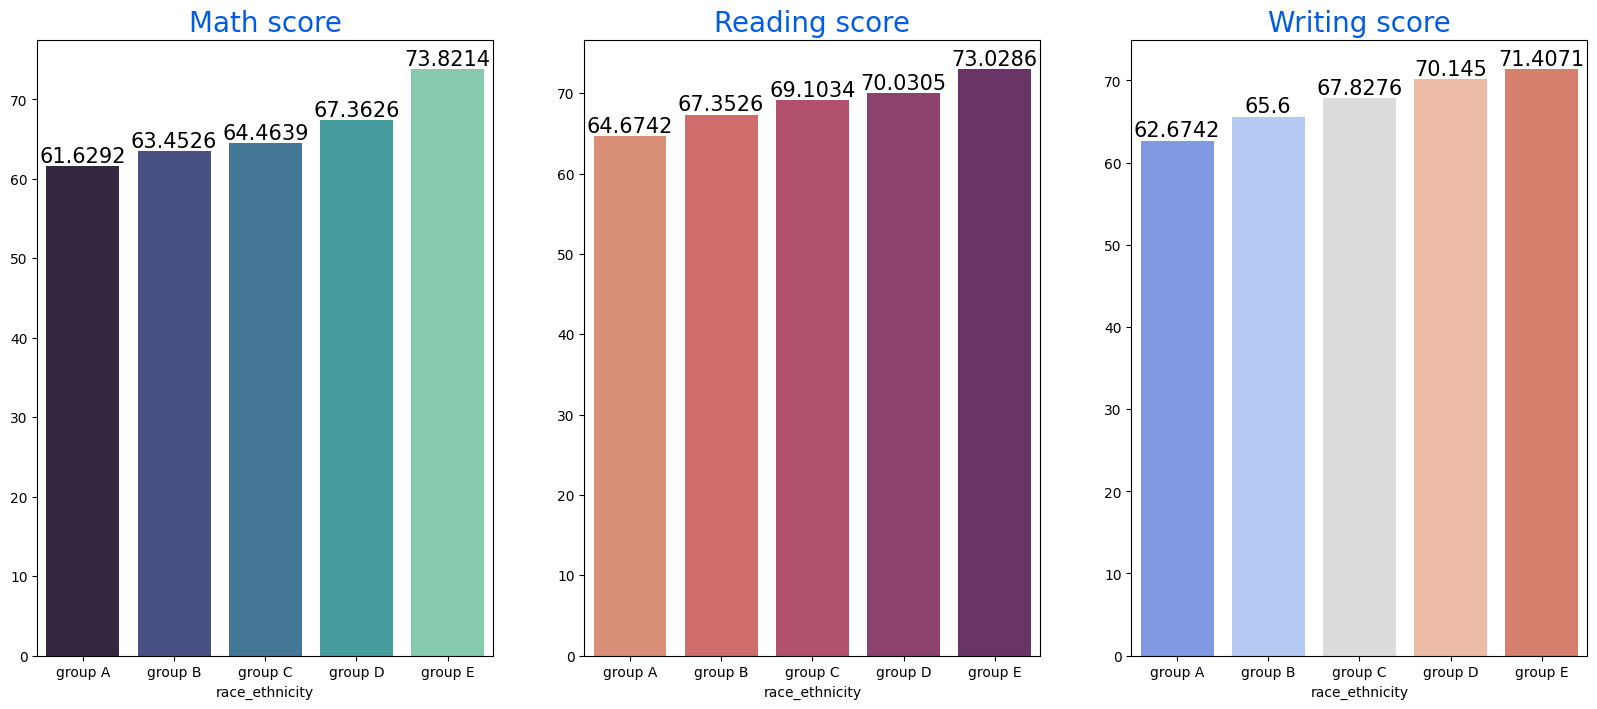

In [39]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Race_group['math_score'].index,y=Race_group['math_score'].values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Race_group['reading_score'].index,y=Race_group['reading_score'].values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Race_group['writing_score'].index,y=Race_group['writing_score'].values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

--> Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 5.4.3 PARENTAL LEVEL OF EDUCATION COLUMN

- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

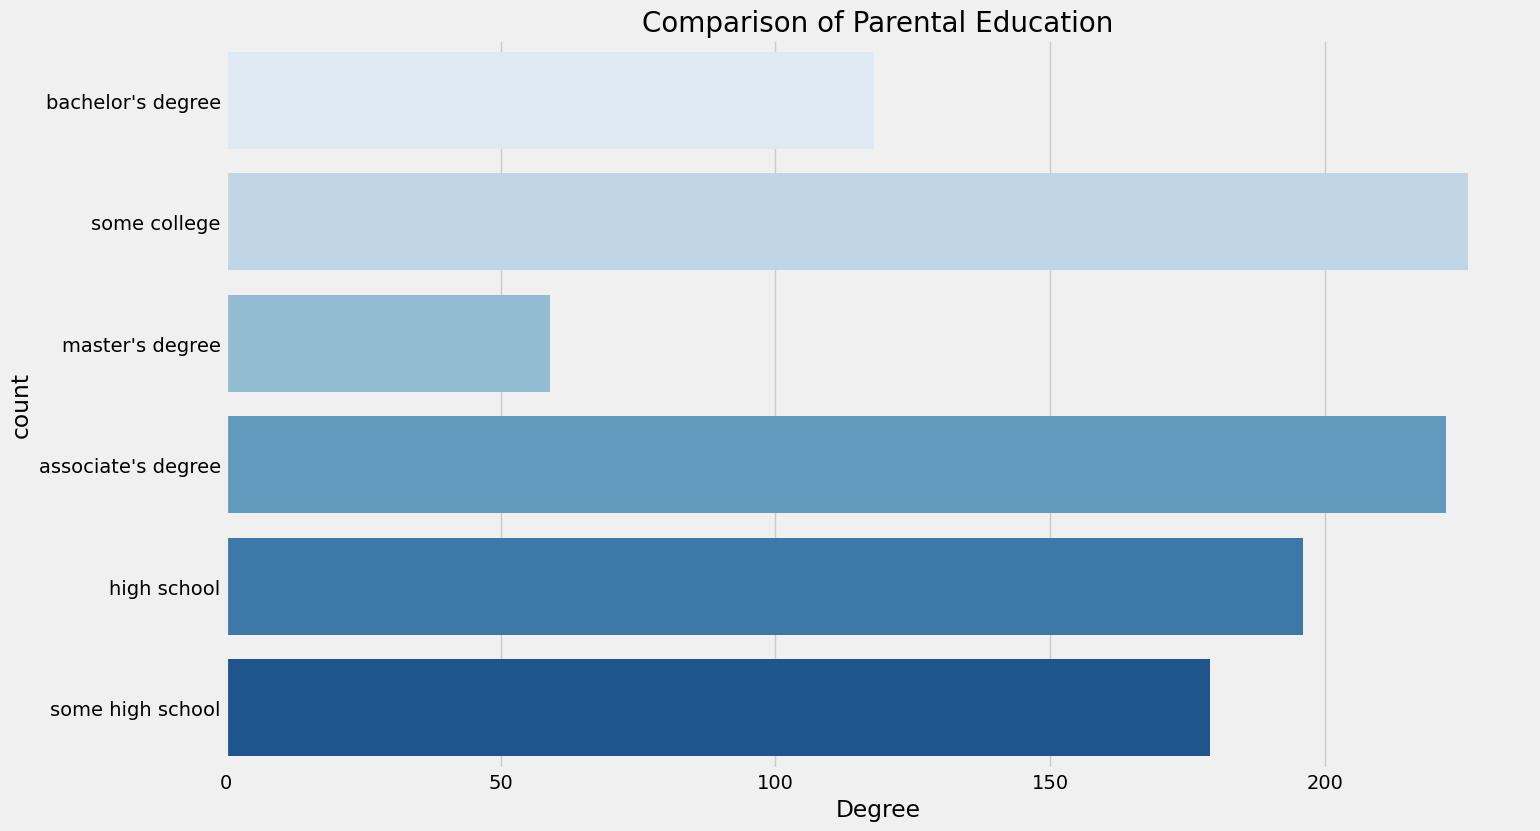

In [41]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

--> Insights 
- Largest number of parents are from some college.

##### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

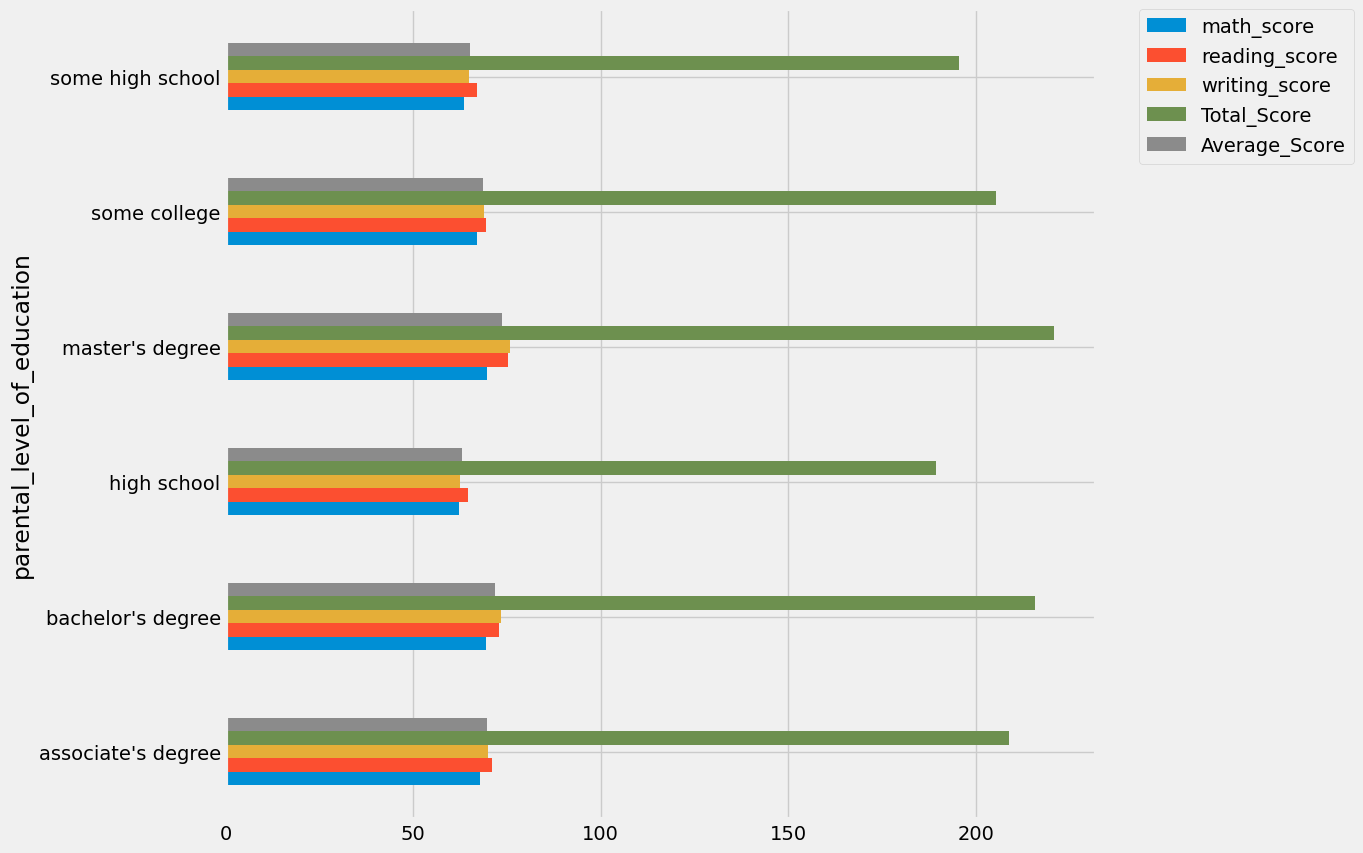

In [44]:
df.groupby('parental_level_of_education')[df.select_dtypes(include='number').columns].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

--> Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 5.4.4 LUNCH COLUMN 


- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?

##### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

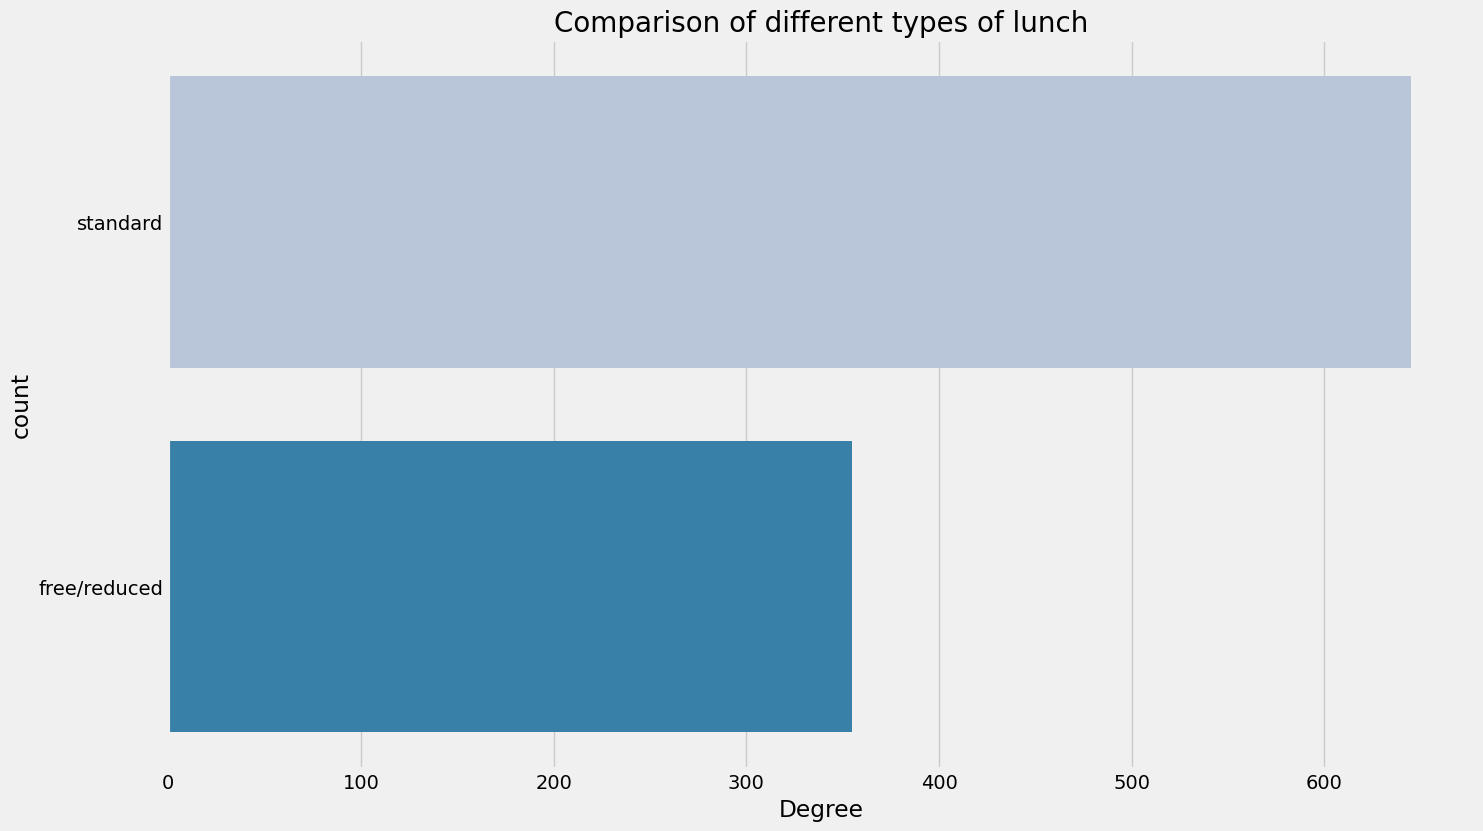

In [47]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

--> Insights 
- Students being served Standard lunch was more than free lunch

##### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

In [49]:
lunch_group=df.groupby('lunch')[df.select_dtypes(include='number').columns].mean()
lunch_group

,math_score,reading_score,writing_score,Total_Score,Average_Score
lunch,,,,,
free/reduced,58.921127,64.653521,63.022535,186.597183,62.199061
standard,70.034109,71.654264,70.823256,212.511628,70.837209


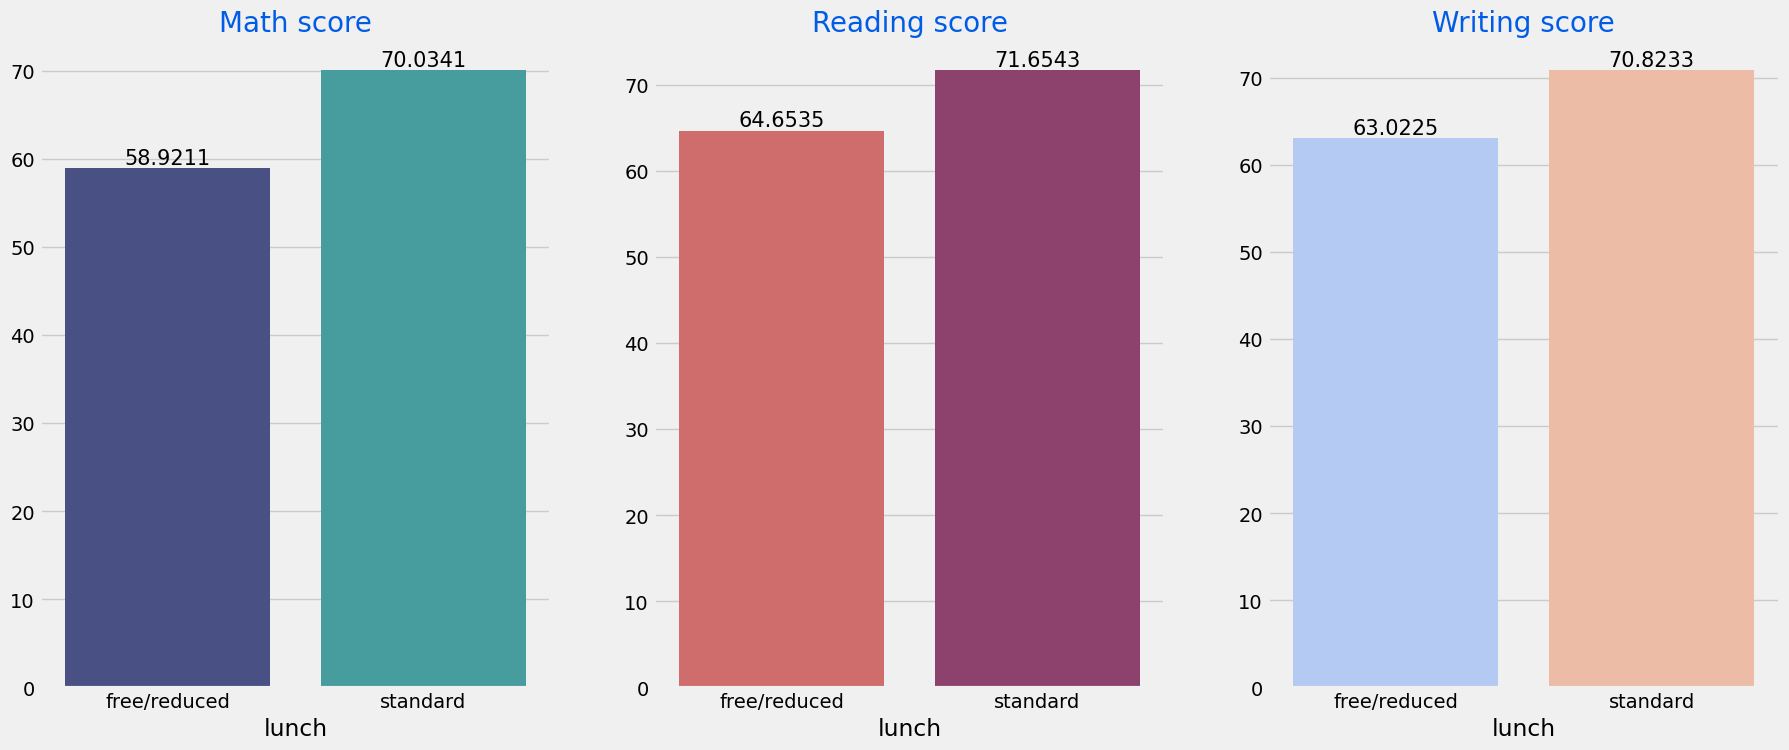

In [50]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=lunch_group['math_score'].index,y=lunch_group['math_score'].values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=lunch_group['reading_score'].index,y=lunch_group['reading_score'].values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=lunch_group['writing_score'].index,y=lunch_group['writing_score'].values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

--> Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 5.4.5 TEST PREPARATION COURSE COLUMN 

- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( Which type of test preperation course is most common amoung students ? )

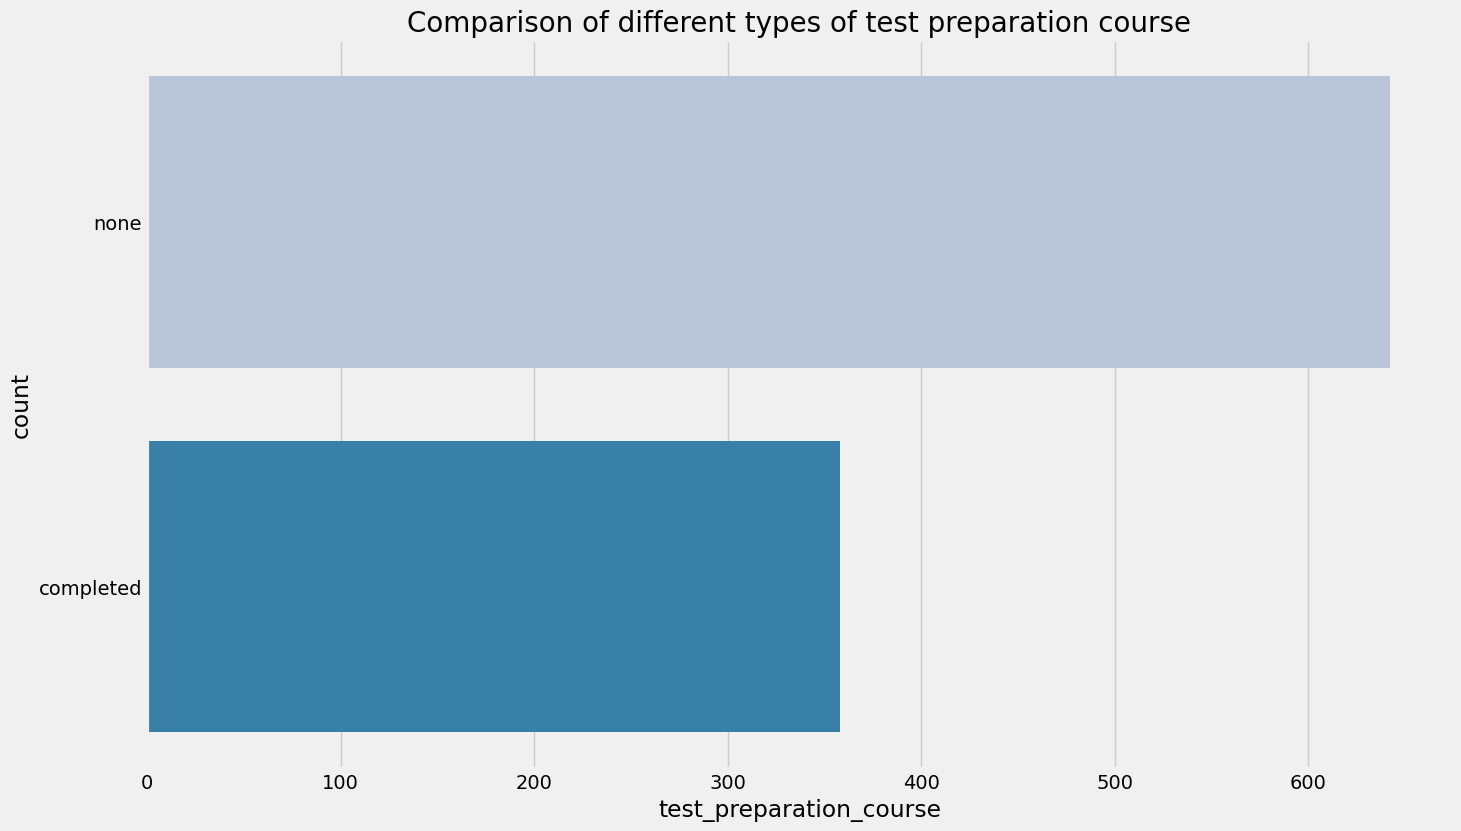

In [51]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['test_preparation_course'], palette = 'PuBu')
plt.title('Comparison of different types of test preparation course', fontweight = 30, fontsize = 20)
plt.xlabel('test_preparation_course')
plt.ylabel('count')
plt.show()

##### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

In [54]:
test_group=df.groupby('test_preparation_course')[df.select_dtypes(include='number').columns].mean()
test_group

,math_score,reading_score,writing_score,Total_Score,Average_Score
test_preparation_course,,,,,
completed,69.695531,73.893855,74.418994,218.008380,72.669460
none,64.077882,66.534268,64.504673,195.116822,65.038941


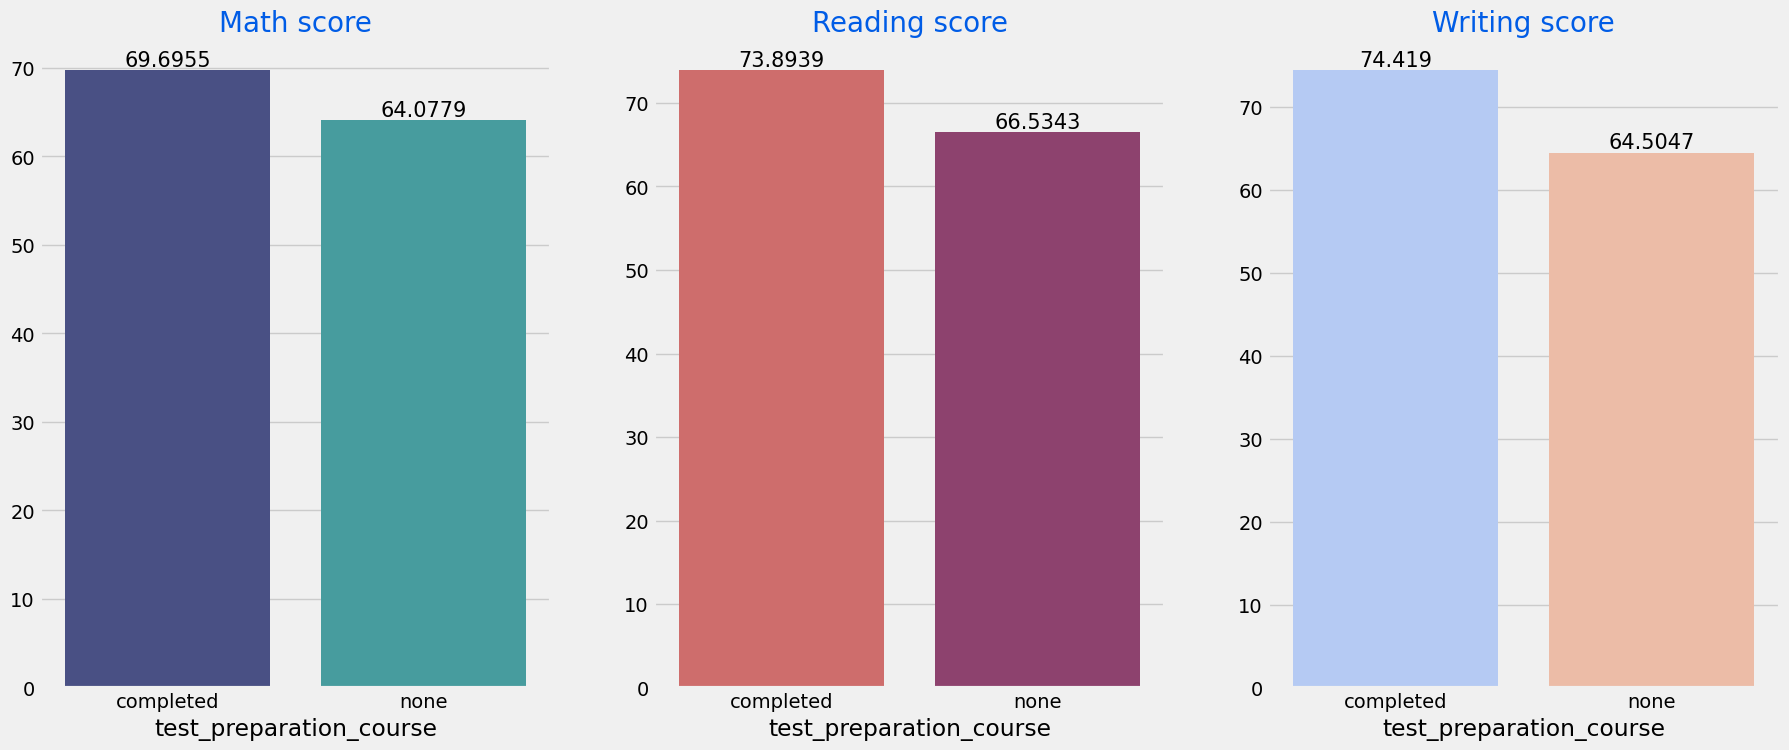

In [55]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=test_group['math_score'].index,y=test_group['math_score'].values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=test_group['reading_score'].index,y=test_group['reading_score'].values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=test_group['writing_score'].index,y=test_group['writing_score'].values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

--> Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 5.4.6 CHECKING OUTLIERS

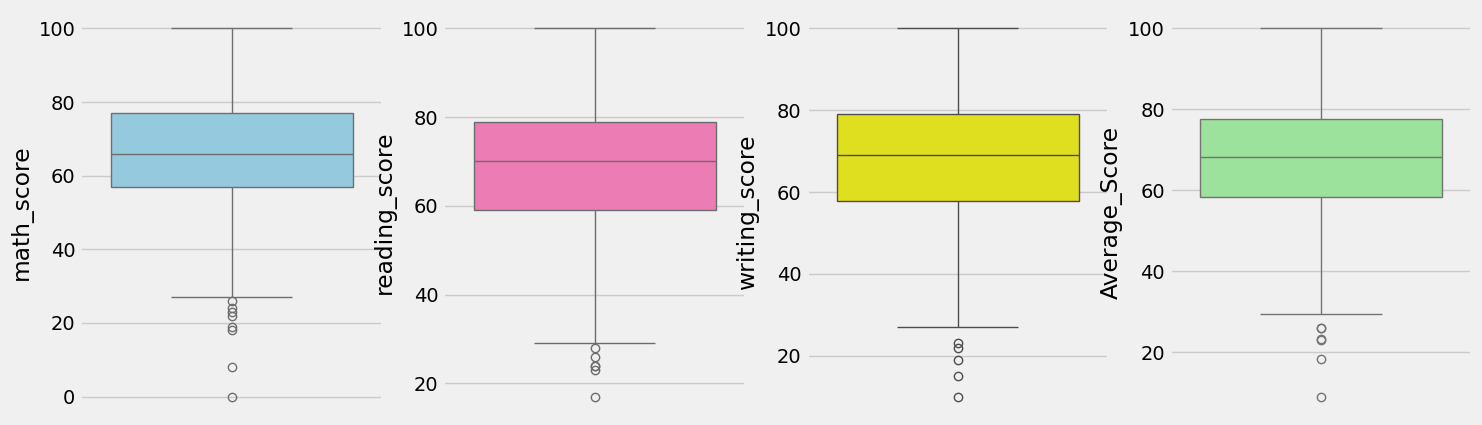

In [56]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average_Score'],color='lightgreen')
plt.show()

#### 5.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

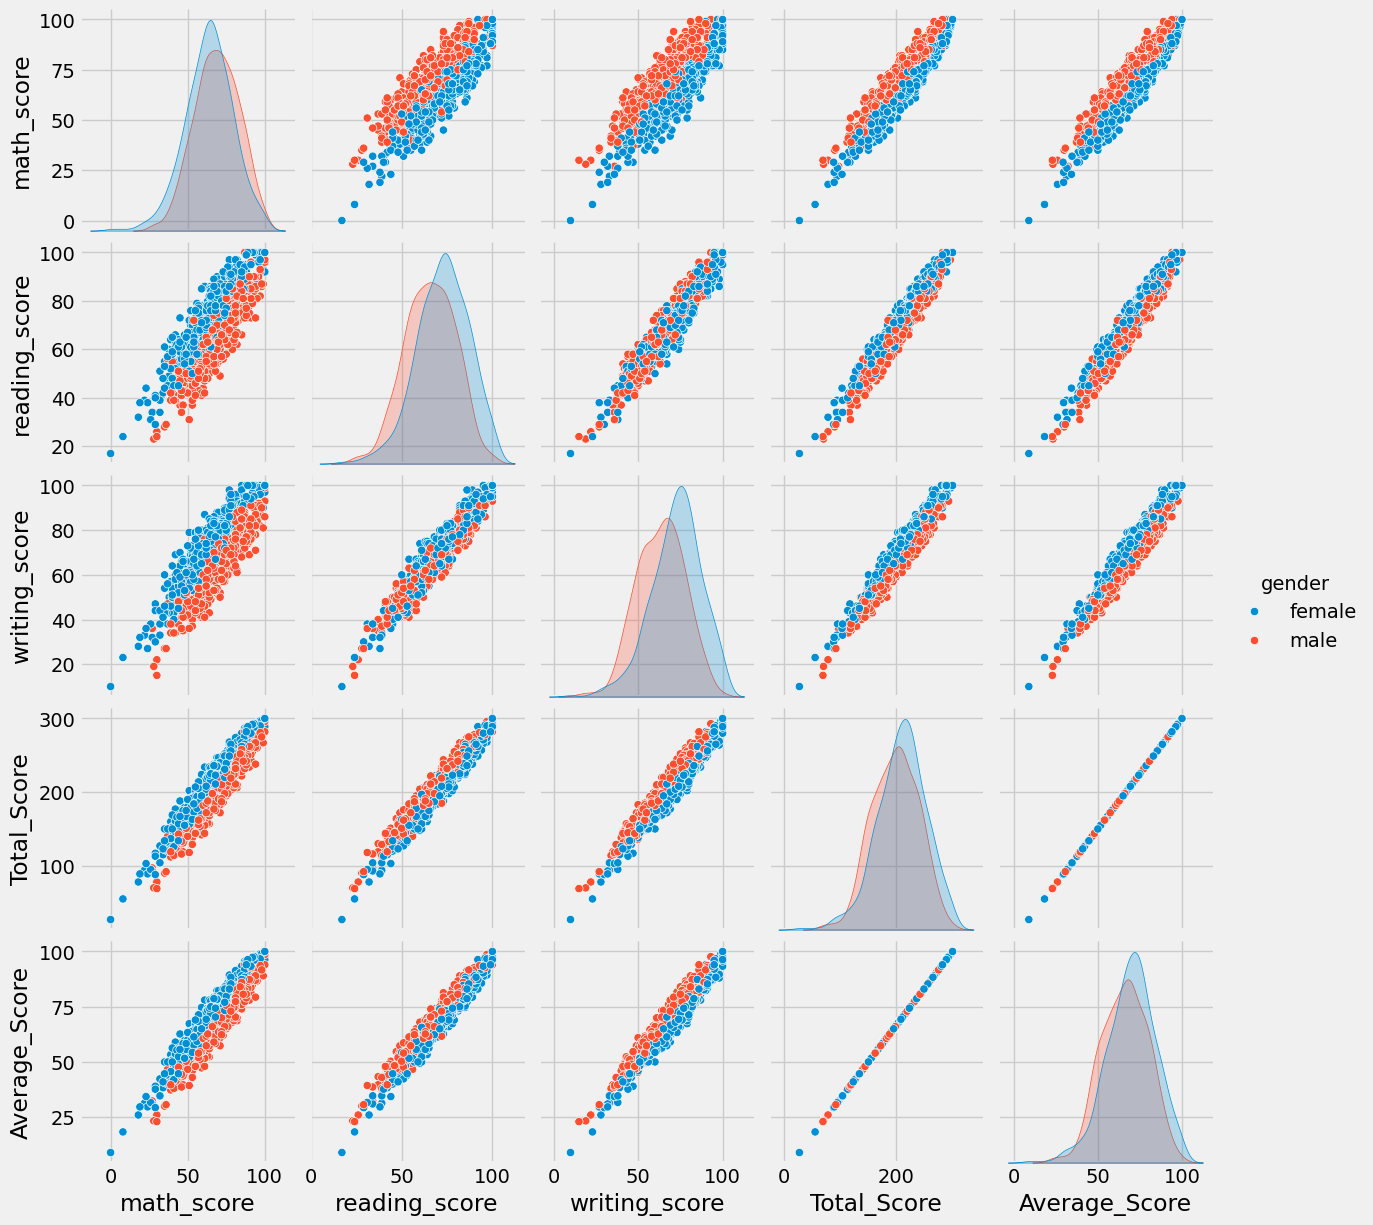

In [57]:
sns.pairplot(df,hue = 'gender')
plt.show()

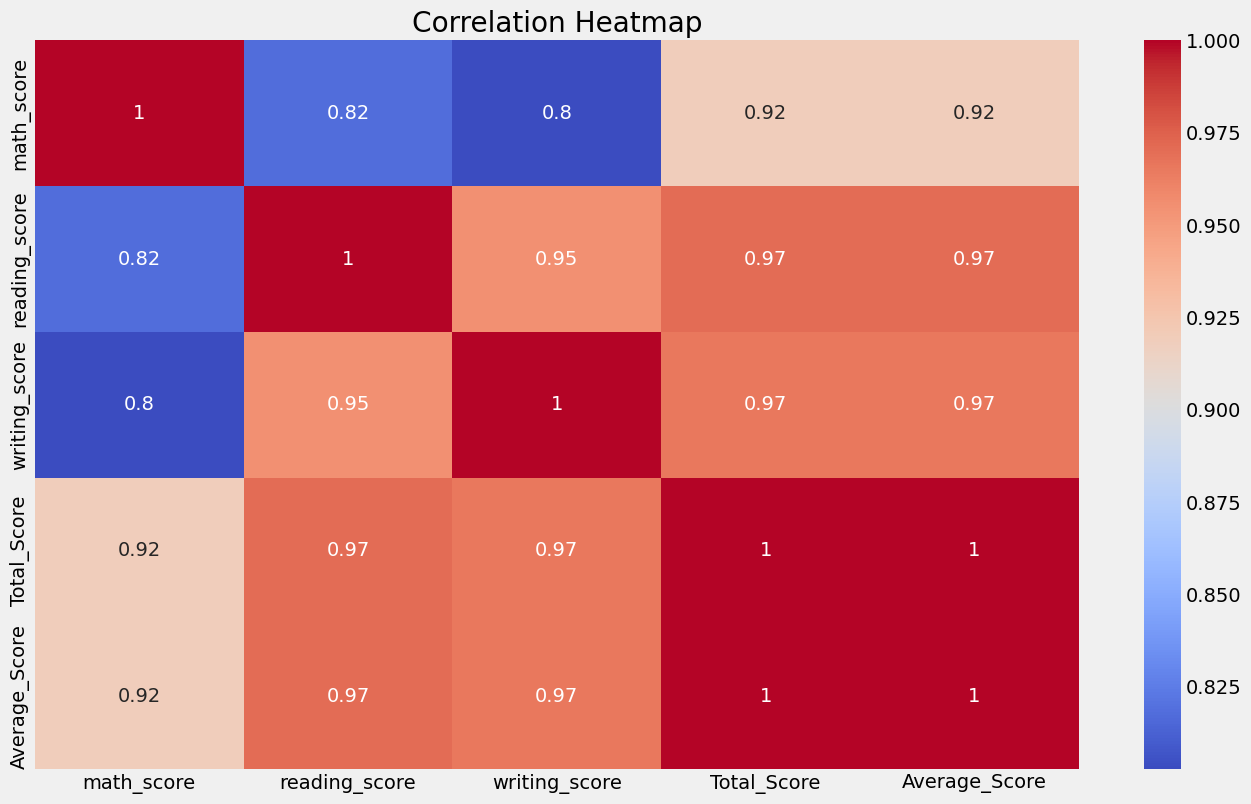

In [60]:
numeric_df = df.select_dtypes(include=['number'])

# Generate the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 6. Conclusion

- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.